# Mapping Heat Vulnerability Across Amsterdam
### An integrated index for prioritising urban cooling interventions

*Computational Social Science — group project*

---

## 1. Introduction

Heatwaves are the deadliest climate hazard in the Netherlands, and Amsterdam is
warming faster than the surrounding countryside because of the **urban heat-island
(UHI) effect**: dark, sealed surfaces absorb solar radiation during the day and
release it slowly at night, while a lack of vegetation and water removes the natural
cooling that evapotranspiration and shade would otherwise provide. The 2019 and 2022
heatwaves both produced measurable excess mortality, concentrated among elderly and
socially isolated residents.

Following the IPCC framing, **heat risk is not the same as heat exposure**. Risk is the
interaction of a *hazard* (high temperatures), the *exposure* of people to that hazard,
and their *vulnerability* — which combines **sensitivity** (who is harmed most, e.g. the
elderly, the chronically ill, low-income and socially isolated residents) and
**adaptive capacity** (whether people can escape the heat: access to green space, water,
and public cooled spaces). Two neighbourhoods can be equally hot while facing very
different risk, because their populations and their access to relief differ.

The City of Amsterdam already publishes climate-risk maps and a community-facing
"koeltekaart" (cooling map). What is missing is an **integrated, neighbourhood-level
prioritisation**: a single, defensible ranking that tells policymakers *where the people
most vulnerable to heat also have the least access to cooling*, and *which interventions
would deliver the most benefit*. That is the gap this project addresses.

### Research questions

1. **RQ1 — Drivers.** Which physical-environmental characteristics of a neighbourhood
   (impervious surface, public/private greenery, surface water, tree canopy) explain its
   heat risk?
2. **RQ2 — Double disadvantage.** Are socially vulnerable neighbourhoods also the ones
   with the *poorest* access to cooling infrastructure, and does this gap widen for the
   most vulnerable?
3. **RQ3 — Composite index.** Can we combine heat exposure, social vulnerability and
   cooling access into a single, statistically robust **Heat Vulnerability Index (HVI)**
   that tiers neighbourhoods for action?
4. **RQ4 — Where to act.** Where are the statistically significant heat-vulnerability
   *clusters*, and which neighbourhoods offer the greatest return on cooling
   investment (the "green deserts" that need both trees and shelters)?

### Approach in one paragraph

We assemble a neighbourhood (*buurt*) level dataset from official open sources, engineer
the physical and social features described above, and answer each research question with
an appropriate method — robust OLS regression for the drivers, a standardised additive
index for social vulnerability, quantile regression for the access gap, a weighted
composite for the HVI (with bootstrap and weight-sensitivity checks), and local spatial
autocorrelation (Moran's *I* / LISA) to locate clusters. The outputs feed a policy
dashboard.

---
## 2. Environment & configuration

The analysis uses the standard scientific-Python stack plus `geopandas`/`libpysal`/`esda`
for the spatial work. All packages are pinned in `requirements.txt`; from a clean
environment:

```bash
pip install -r requirements.txt
```

The notebook resolves the repository root automatically, so it runs unchanged whether it
is launched from the repo root or from the `Data_analysis/` folder.

In [1]:
import json, re, unicodedata, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as scs
from scipy.stats import pearsonr, spearmanr, shapiro, normaltest, jarque_bera, probplot, chi2
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local
import mapclassify

warnings.filterwarnings("ignore")           # silence benign geopandas/statsmodels notes
pd.set_option("display.max_columns", 60)
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "font.size": 10})

# Amsterdam Design System palette (so figures match the city's house style)
AMS_BLUE, AMS_RED, AMS_GREEN = "#004699", "#ec0000", "#00893c"
AMS_ORANGE, AMS_INFO, AMS_PURPLE = "#ff9100", "#009de6", "#a00078"

# Resolve repository root (folder that contains both data/ and Data_analysis/)
def find_repo_root():
    here = Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / "data").is_dir() and (cand / "Data_analysis").is_dir():
            return cand
    raise FileNotFoundError("Could not locate repository root from " + str(here))

BASE = find_repo_root()
INPUTS  = BASE / "Data_analysis" / "inputs"                  # cleaned input tables
OUT     = BASE / "Data_analysis" / "outputs"                # figures & exports
DATA    = BASE / "data"
OUT.mkdir(exist_ok=True)
print("Repository root:", BASE)

Repository root: /Users/nojusstankevicius/Documents/GitHub/koeltekaart-amsterdam


### Shared helpers

Two small utilities are used throughout and are defined once here so their behaviour is
explicit:

- **`clean_cbs`** — Statistics Netherlands (CBS) encodes *missing/suppressed* values as the
  sentinel `-99999999` rather than leaving cells blank. If we did not convert these to
  `NaN` they would silently destroy every mean, correlation and regression. This function
  replaces the sentinel with `NaN`.
- **`norm_name`** — our datasets come from three different administrations and spell buurt
  names inconsistently (hyphens vs. spaces, the abbreviation "e.o." for *en omgeving* —
  sometimes mangled into `e0o0` by a bad encoding, and diacritics). Normalising names to a
  canonical form lets us join on name with near-complete coverage instead of losing
  neighbourhoods to spelling differences.

In [2]:
CBS_NA = -99999990   # CBS suppressed-value sentinel is -99999999

def clean_cbs(s: pd.Series) -> pd.Series:
    "Replace the CBS missing-value sentinel (-99999999) with NaN."
    return s.where(s > CBS_NA, np.nan)

def norm_name(s: str) -> str:
    "Canonical buurt-name key for robust joining across sources."
    if not isinstance(s, str):
        return ""
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode().lower()
    s = s.replace("e0o0", " ")                 # repair mangled "e.o."
    s = re.sub(r"\be\.?\s*o\.?\b", " ", s)     # drop "e.o." / "e o" (en omgeving)
    s = re.sub(r"[^a-z0-9]+", " ", s)          # punctuation & hyphens -> space
    return re.sub(r"\s+", " ", s).strip()

---
## 3. Data and provenance

Every variable in this study comes from an official open dataset. We deliberately separate
**what we engineered ourselves from raw files in this repository** (fully reproducible
here) from **upstream layers built in QGIS / Google Earth Engine** by our group, for which
the raw services are not redistributable and which we therefore document precisely instead
of regenerating.

| Dataset | Source | Granularity | What we use it for | Reproduced here? |
|---|---|---|---|---|
| **CBS Kerncijfers wijken en buurten 2022** | Statistics Netherlands (CBS), via the PDOK *buurten* WFS in QGIS | buurt | Demographics, income, housing, amenity distances → social vulnerability & cooling-access proxy | Loaded from `ams_features.csv` (CBS columns documented below) |
| **Surface temperature (LST)** | Landsat 8 Collection-2 L2 (`LANDSAT/LC08/C02/T1_L2`), summer median 2023, band `ST_B10`, via Google Earth Engine | 30 m raster → buurt mean | Heat exposure (`temp_mean`) | Documented (GEE script in appendix); zonal mean precomputed into `ams_features.csv` |
| **NDVI (greenness)** | Landsat 8, same GEE composite | 30 m raster → buurt mean | Vegetation cover (`ndvi_mean`) | Documented; precomputed |
| **Water / road surface share** | PDOK BGT `waterdeel` & `wegdeel` WFS, intersected with buurten in QGIS | buurt | Physical drivers (`water_prc`, `road_prc`) | Documented (WFS service, not a saved file) |
| **Climate-risk scores** | Gemeente Amsterdam *Klimaatrisicokaarten* (Klimaateffectatlas), heat module | buurt | Official heat-risk index `HI_TOTAAL_S.0` and its drought (`DR_`) drivers | Loaded from `climate_risk_scores.csv` |
| **Street trees** | Gemeente Amsterdam open data — *Bomen* (≈322k individual trees, RD-New coordinates) | point | Tree density, maturity, species richness | **Yes** — spatial-joined here from `trees_raw.json` |
| **Cooling locations (koelteplekken)** | Project-curated list of public cooled/water spots | point (12) | Gap analysis: which vulnerable buurten lack a nearby shelter | **Yes** — from `data/koeltekaart_data.csv` |
| **Buurt boundaries** | CBS/PDOK *Wijk- en buurtkaart 2022* | polygon | Spatial join, centroids, contiguity weights, mapping | **Yes** — geometry from `buurten_geometry.geojson` |

> **A note on `ams_features.csv`.** This table is our group's feature build: the CBS 2022
> *Kerncijfers* joined with the GEE/PDOK raster-derived columns above. Because the GEE and
> PDOK layers were produced through interactive services (not saved files), this notebook
> treats `ams_features.csv` as a documented upstream input rather than rebuilding the
> remote-sensing extraction. Everything *downstream* of it — the joins, the tree
> aggregation, every index and model — is reproduced from scratch below.

In [3]:
# ---- 3.1 Base feature table (CBS 2022 + GEE/PDOK spatial layers) ----------
ams = pd.read_csv(INPUTS / "ams_features.csv", low_memory=False)
for c in ams.select_dtypes("number").columns:
    ams[c] = clean_cbs(ams[c])
ams["key"] = ams["buurtnaam"].map(norm_name)
df = ams.copy()
print(f"Loaded ams_features: {df.shape[0]} buurten x {df.shape[1]} columns")
print(f"Temperature range: {df.temp_mean.min():.1f}-{df.temp_mean.max():.1f} C "
      f"(mean {df.temp_mean.mean():.1f} C)")

Loaded ams_features: 481 buurten x 208 columns
Temperature range: 21.7-41.5 C (mean 35.4 C)


In [4]:
# ---- 3.2 Buurt boundaries (geometry only) --------------------------------
geo = gpd.read_file(INPUTS / "buurten_geometry.geojson")[["buurtnaam", "geometry"]].copy()
geo["key"] = geo["buurtnaam"].map(norm_name)
geo = geo.dissolve(by="key", as_index=False)               # one polygon per buurt
geo = geo.set_crs(4326, allow_override=True).to_crs(28992)  # RD-New (metres)
matched = geo["key"].isin(df["key"]).sum()
print(f"Buurt polygons: {len(geo)} (matched to features: {matched}/{df['key'].nunique()})")

Buurt polygons: 498 (matched to features: 477/480)


In [5]:
# ---- 3.3 Official climate-risk (heat) scores -----------------------------
crd = pd.read_csv(INPUTS / "climate_risk_scores.csv", low_memory=False)
for c in crd.select_dtypes("number").columns:
    crd[c] = clean_cbs(crd[c])

# The risk table prefixes names with "RK_"; strip it, then normalise.
crd["key"] = crd["name"].str.replace(r"^RK_", "", regex=True).map(norm_name)
risk_cols = [c for c in crd.columns if c.split("_")[0] in ("HI", "DR", "WO", "AA")]

# Exact key join, with a conservative fuzzy fallback for the few residual spellings.
import difflib
ams_keys = df["key"].tolist()
def resolve_key(k):
    if k in set(ams_keys):
        return k
    hit = difflib.get_close_matches(k, ams_keys, n=1, cutoff=0.88)
    return hit[0] if hit else None

crd["key"] = crd["key"].map(resolve_key)
n_unmatched = crd["key"].isna().sum()
crd_buurt = crd.dropna(subset=["key"]).groupby("key")[risk_cols].mean().reset_index()
df = df.merge(crd_buurt, on="key", how="left")

cov = df["HI_TOTAAL_S.0"].notna().sum()
print(f"Climate-risk scores merged on {len(risk_cols)} columns.")
print(f"HI_TOTAAL_S.0 coverage: {cov}/{len(df)} buurten ({cov/len(df)*100:.1f}%)")
print(f"Risk records with no Amsterdam buurt match: {n_unmatched} "
      f"(these are former Weesp neighbourhoods, outside the CBS Amsterdam buurt set)")

Climate-risk scores merged on 96 columns.
HI_TOTAAL_S.0 coverage: 479/481 buurten (99.6%)
Risk records with no Amsterdam buurt match: 19 (these are former Weesp neighbourhoods, outside the CBS Amsterdam buurt set)


---
## 4. Tree canopy (feature engineering)

Street trees are the single most cost-effective cooling intervention a city controls, so we
want a per-buurt measure of canopy. The open-data tree register gives ~322,000 individual
trees as points in the Dutch **RD-New** coordinate system (EPSG:28992).

**Method.** Rather than relying on the trees' own (inconsistently named) buurt labels, we
perform a **spatial join**: each tree point is assigned to the buurt polygon that contains
it. This is geometrically exact and independent of naming. We then derive, per buurt:

- `tree_count` and `tree_density_per_km2` — canopy quantity, area-normalised;
- `pct_mature` — share of trees ≥12 m tall (mapped from the height class), since mature
  canopy delivers far more shade and evapotranspiration than saplings;
- `tree_species_richness` — a simple resilience proxy (monocultures are vulnerable to
  disease, e.g. Dutch elm).

In [6]:
trees = json.load(open(INPUTS / "trees_raw.json"))
tp = pd.DataFrame([{**t["properties"],
                    "x": t["geometry"]["coordinates"][0],
                    "y": t["geometry"]["coordinates"][1]}
                   for t in trees
                   if t.get("geometry") and t["geometry"].get("coordinates")])
tg = gpd.GeoDataFrame(tp, geometry=gpd.points_from_xy(tp.x, tp.y), crs=28992)

HEIGHT_M = {"a. tot 6 m.": 3.0, "b. 6 tot 9 m.": 7.5, "c. 9 tot 12 m.": 10.5,
            "d. 12 tot 15 m.": 13.5, "e. 15 tot 18 m.": 16.5,
            "f. 18 tot 24 m.": 21.0, "g. 24 m. en hoger": 26.0}
MATURE = {"d. 12 tot 15 m.", "e. 15 tot 18 m.", "f. 18 tot 24 m.", "g. 24 m. en hoger"}
tg["height_m"]   = tg["boomhoogteklasse_actueel"].map(HEIGHT_M)
tg["is_mature"]  = tg["boomhoogteklasse_actueel"].isin(MATURE)

joined = gpd.sjoin(tg, geo[["key", "geometry"]], how="inner", predicate="within")
tree_agg = (joined.groupby("key")
            .agg(tree_count=("id", "count"),
                 pct_mature=("is_mature", "mean"),
                 mean_height_m=("height_m", "mean"),
                 tree_species_richness=("soortnaam_top", lambda x: x.dropna().nunique()))
            .reset_index())
tree_agg["pct_mature"] = (tree_agg["pct_mature"] * 100).round(1)

df = df.merge(tree_agg, on="key", how="left")
df["tree_density_per_km2"] = (df["tree_count"] / (df["buurt_area"] / 1e6)).round(1)

print(f"Trees placed by spatial join: {len(joined):,}/{len(tg):,} "
      f"({len(joined)/len(tg)*100:.1f}%)")
print(f"Buurten with tree data: {df['tree_count'].notna().sum()}/{len(df)}")
print(f"Tree density: median {df.tree_density_per_km2.median():.0f}, "
      f"mean {df.tree_density_per_km2.mean():.0f} trees/km2")

Trees placed by spatial join: 311,618/321,717 (96.9%)
Buurten with tree data: 473/481
Tree density: median 2147, mean 2290 trees/km2


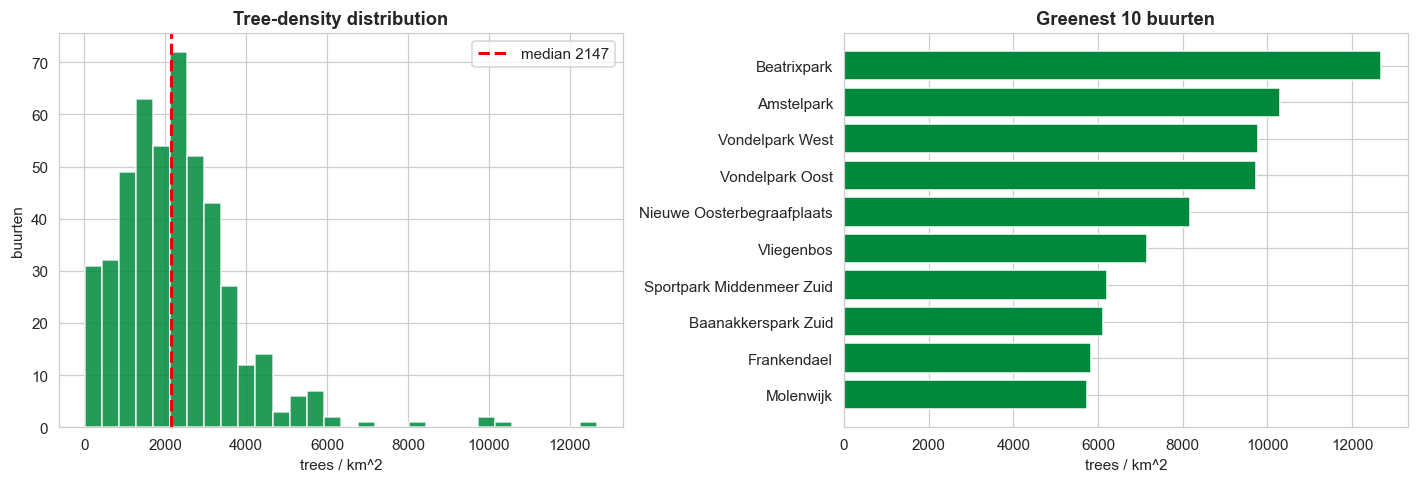

Low-canopy buurten (<500 trees/km^2): 38


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
d = df["tree_density_per_km2"].dropna()
ax[0].hist(d, bins=30, color=AMS_GREEN, alpha=0.85, edgecolor="white")
ax[0].axvline(d.median(), color=AMS_RED, ls="--", lw=2, label=f"median {d.median():.0f}")
ax[0].set(xlabel="trees / km^2", ylabel="buurten", title="Tree-density distribution")
ax[0].legend()
top = df.nlargest(10, "tree_density_per_km2")[["buurtnaam", "tree_density_per_km2"]].dropna()
ax[1].barh(top.buurtnaam, top.tree_density_per_km2, color=AMS_GREEN)
ax[1].invert_yaxis(); ax[1].set(xlabel="trees / km^2", title="Greenest 10 buurten")
plt.tight_layout(); plt.savefig(OUT / "fig_tree_density.png", bbox_inches="tight"); plt.show()
print("Low-canopy buurten (<500 trees/km^2):", int((df.tree_density_per_km2 < 500).sum()))

---
## 5. Cooling access (feature engineering)

"Adaptive capacity" needs an operational measure of how easily residents can reach relief
from heat. We build two complementary measures.

**(a) Cooling-access proxy (used in the HVI).** Amsterdam has only a handful of officially
designated cooling shelters (see below), far too few to compute a meaningful per-buurt
access score for all 481 neighbourhoods. Instead we proxy adaptive capacity with the CBS
average distances to the kinds of *public, cooled or water-based spaces that actually serve
as heat refuges* — a **swimming pool**, a **public library**, and a **large supermarket**.
These three match the dominant categories in the official koelteplek list (libraries,
supermarkets, and water/leisure sites), are reliably air-conditioned or water-based, and are
densely distributed across the city. (We deliberately exclude train stations, used in an
earlier draft: a station is a transit node, not a place people go to cool down.) We min–max
normalise each distance, invert it (so nearer = better), and average. This has near-complete
coverage and a clear interpretation.

**(b) Real shelter gap (used for prioritisation).** Separately, we compute the true
straight-line distance from each buurt centroid to the nearest of the 12 official
*koelteplekken*. With so few shelters this is intentionally a **gap diagnostic**: it shows
how sparse the official network is and which vulnerable areas are left uncovered — a direct
input to the policy recommendations rather than to the index itself.

In [8]:
def norm01(s):
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng > 0 else s * 0 + 0.5

# (a) amenity-based cooling-access proxy
cool_vars = [v for v in ["zwembadGemiddeldeAfstandInKm",
                         "bibliotheekGemiddeldeAfstandInKm",
                         "groteSupermarktGemiddeldeAfstandInKm"] if v in df]
access = df[cool_vars].apply(norm01)
df["cooling_access"] = (1 - access).mean(axis=1)            # higher = better access
print("Cooling-access proxy from:", cool_vars)
print(f"  mean {df.cooling_access.mean():.3f}; coverage "
      f"{df.cooling_access.notna().sum()}/{len(df)} "
      f"(the {df.cooling_access.isna().sum()} without data are non-residential: "
      f"parks, harbours, cemeteries, empty new islands)")

# (b) real distance to nearest official koelteplek (gap diagnostic)
koel = pd.read_csv(DATA / "koeltekaart_data.csv").dropna(subset=["latitude", "longitude"])
kg = gpd.GeoDataFrame(koel, geometry=gpd.points_from_xy(koel.longitude, koel.latitude),
                      crs=4326).to_crs(28992)
cent = geo.copy(); cent["geometry"] = cent.geometry.centroid
cent["dist_koelteplek_m"] = cent.geometry.apply(lambda p: float(kg.distance(p).min()))
df = df.merge(cent[["key", "dist_koelteplek_m"]], on="key", how="left")
print(f"\nOfficial koelteplekken: {len(kg)}")
print(f"  median buurt->nearest shelter: {df.dist_koelteplek_m.median():.0f} m")
print(f"  buurten within a 500 m walk of a shelter: {(df.dist_koelteplek_m<=500).sum()}")

Cooling-access proxy from: ['zwembadGemiddeldeAfstandInKm', 'bibliotheekGemiddeldeAfstandInKm', 'groteSupermarktGemiddeldeAfstandInKm']
  mean 0.838; coverage 449/481 (the 32 without data are non-residential: parks, harbours, cemeteries, empty new islands)

Official koelteplekken: 12
  median buurt->nearest shelter: 2097 m
  buurten within a 500 m walk of a shelter: 35


---
## 6. Exploratory data analysis

Before modelling we characterise the variables that feed the research questions, grouped
into **physical**, **social** and **cooling/policy** blocks. We check distributions,
normality, outliers, pairwise association and multicollinearity, because these determine
which statistical methods are valid (e.g. whether to trust Pearson vs. Spearman, and
whether the regression standard errors need to be robust).

In [9]:
PHYS  = [v for v in ["temp_mean", "ndvi_mean", "water_prc", "road_prc",
                     "tree_density_per_km2"] if v in df]
SOCIAL = [v for v in ["percentagePersonen65JaarEnOuder", "percentageEenpersoonshuishoudens",
                      "percentageNietWesterseMigratieachtergrond",
                      "percentageHuishoudensOnderOfRondSociaalMinimum",
                      "aantalWmoClientenPer1000Inwoners",
                      "bevolkingsdichtheidInwonersPerKm2"] if v in df]
COOL_POLICY = [v for v in ["cooling_access", "HI_TOTAAL_S.0",
                           "DR_AV_MATE_VAN_VERHARDING_V.0", "DR_BS_GROEN_PUBLIEK_V.0"] if v in df]
KEY = PHYS + SOCIAL + COOL_POLICY

desc = df[KEY].describe().T[["count", "mean", "std", "min", "max"]]
desc["skew"] = df[KEY].skew().round(2)
desc["kurtosis"] = df[KEY].kurt().round(2)
desc["missing"] = df[KEY].isna().sum()
print(f"{len(PHYS)} physical, {len(SOCIAL)} social, {len(COOL_POLICY)} cooling/policy variables\n")
desc.round(2)

5 physical, 6 social, 4 cooling/policy variables



,count,mean,std,min,max,skew,kurtosis,missing
temp_mean,481.0,35.39,2.85,21.70,41.51,-1.36,2.67,0
ndvi_mean,481.0,0.39,0.16,-0.28,0.78,-0.30,0.99,0
water_prc,481.0,1.25,2.70,0.00,34.91,5.84,55.08,0
road_prc,479.0,0.12,0.41,0.00,6.10,9.48,115.63,2
tree_density_per_km2,473.0,2290.33,1497.75,2.10,12685.40,1.95,8.57,8
percentagePersonen65JaarEnOuder,424.0,12.64,7.24,0.00,48.00,0.93,2.04,57
percentageEenpersoonshuishoudens,440.0,54.74,15.77,8.00,100.00,0.11,0.53,41
percentageNietWesterseMigratieachtergrond,424.0,30.63,20.24,2.00,97.00,0.89,-0.08,57
percentageHuishoudensOnderOfRondSociaalMinimum,387.0,11.99,6.16,0.00,39.00,0.88,1.41,94
aantalWmoClientenPer1000Inwoners,379.0,82.85,65.48,6.00,714.00,3.66,25.63,102


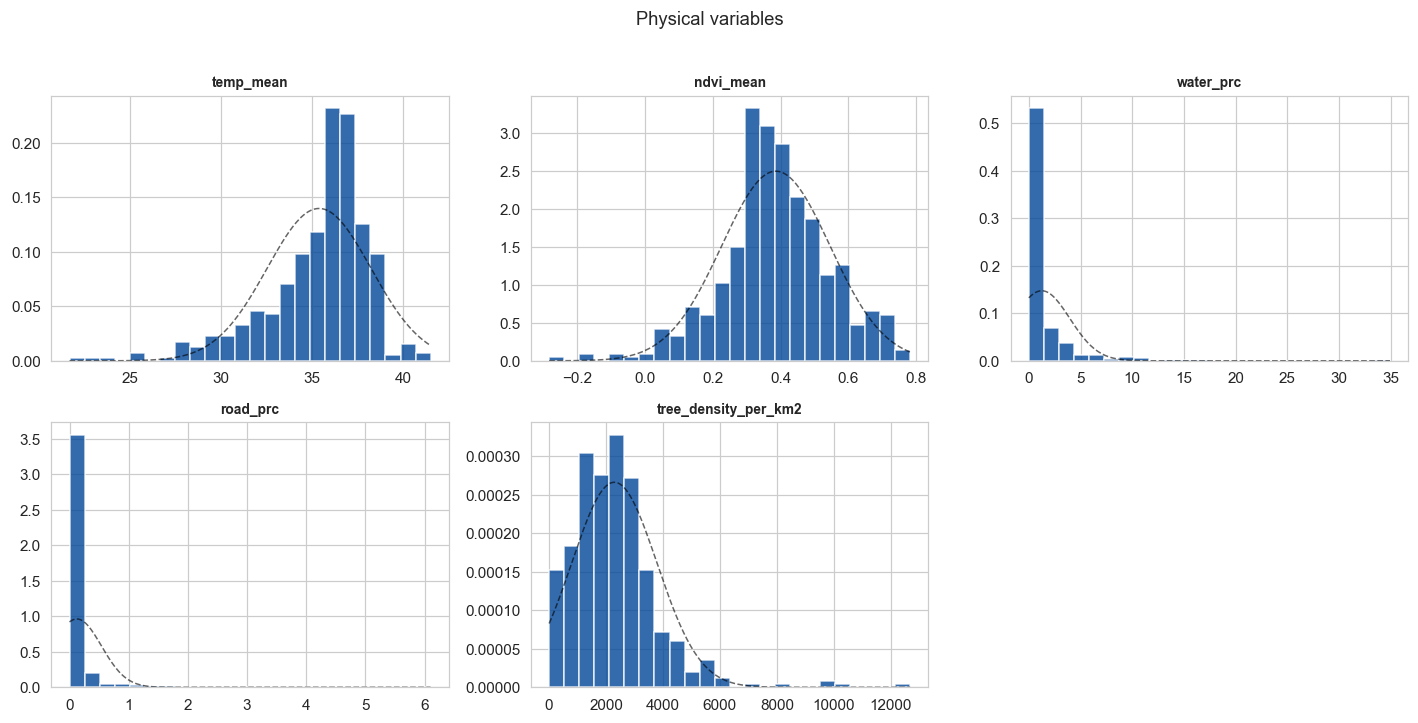

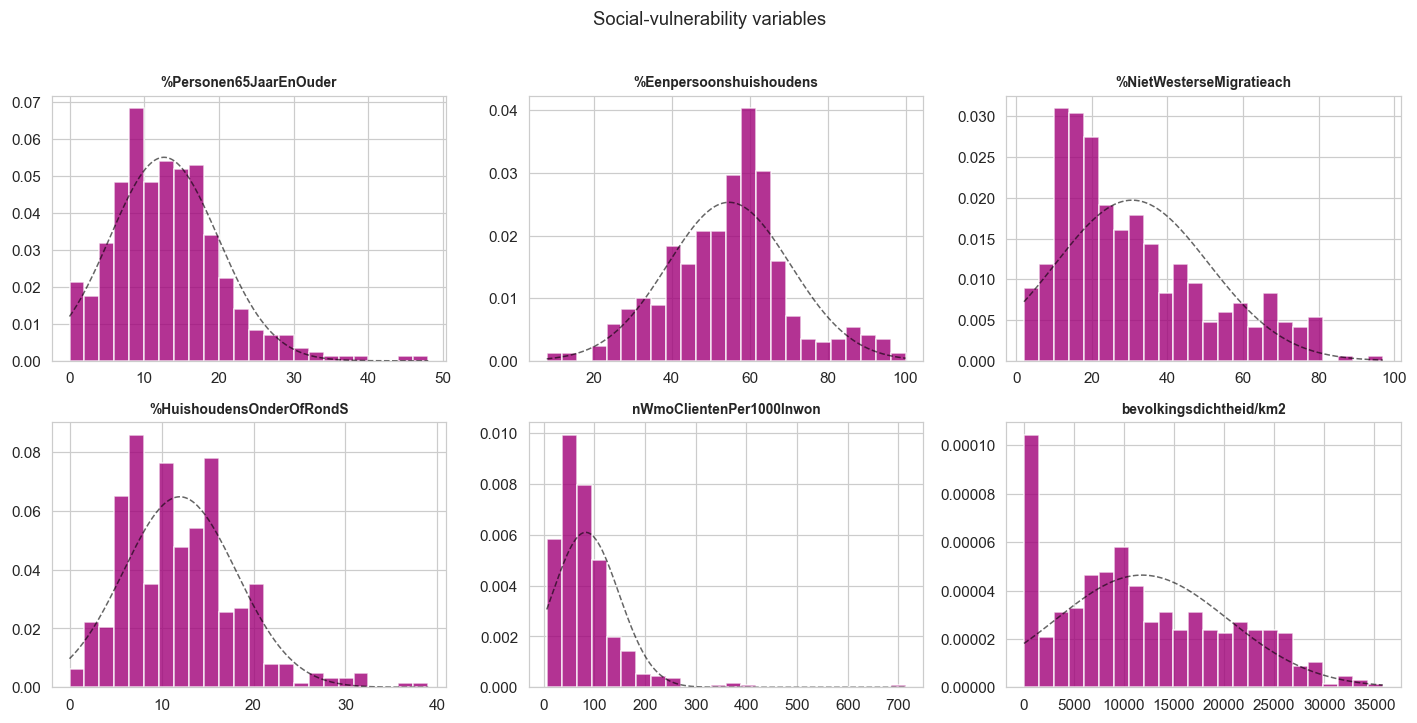

In [10]:
short = lambda v: (v.replace("percentage", "%").replace("Gemiddelde", "")
                    .replace("aantal", "n").replace("InwonersPerKm2", "/km2")[:24])
def hist_block(varlist, title, color):
    n = len(varlist); ncol = 3; nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(13, 3.2 * nrow))
    for ax, v in zip(np.ravel(axes), varlist):
        s = df[v].dropna()
        ax.hist(s, bins=24, color=color, alpha=0.8, density=True, edgecolor="white")
        xs = np.linspace(s.min(), s.max(), 200)
        ax.plot(xs, scs.norm.pdf(xs, s.mean(), s.std()), "k--", lw=1, alpha=0.6)
        ax.set_title(short(v), fontsize=9)
    for ax in np.ravel(axes)[n:]:
        ax.set_visible(False)
    fig.suptitle(title, y=1.02, fontsize=12); plt.tight_layout()
    plt.savefig(OUT / f"fig_hist_{title.split()[0].lower()}.png", bbox_inches="tight"); plt.show()

hist_block(PHYS, "Physical variables", AMS_BLUE)
hist_block(SOCIAL, "Social-vulnerability variables", AMS_PURPLE)

**Reading the distributions.** Several variables are clearly right-skewed (tree density,
the percentage of low-income households, WMO-care clients) with long upper tails, and the
dashed normal curves fit poorly. This already tells us two things: (i) rank-based
**Spearman** correlations will be safer than Pearson for association testing, and (ii)
ordinary regression standard errors may be unreliable, so we will use
**heteroskedasticity-robust (HC3)** errors. We confirm the non-normality formally next.

In [11]:
rows = []
for v in KEY:
    s = df[v].dropna().values
    if len(s) < 8:
        continue
    sw_p = shapiro(s)[1] if len(s) <= 5000 else np.nan
    rows.append({"variable": short(v), "n": len(s),
                 "Shapiro_p": round(sw_p, 4), "DAgostino_p": round(normaltest(s)[1], 4),
                 "JarqueBera_p": round(jarque_bera(s)[1], 4),
                 "normal@.05": "yes" if (np.nan_to_num(sw_p, nan=1) > .05 and
                                          normaltest(s)[1] > .05) else "no"})
norm_df = pd.DataFrame(rows)
n_norm = (norm_df["normal@.05"] == "yes").sum()
print(f"{n_norm}/{len(norm_df)} variables are normally distributed at alpha=0.05.")
print("-> Non-normality justifies Spearman correlations and HC3-robust regression below.\n")
norm_df

0/15 variables are normally distributed at alpha=0.05.
-> Non-normality justifies Spearman correlations and HC3-robust regression below.



,variable,n,Shapiro_p,DAgostino_p,JarqueBera_p,normal@.05
0,temp_mean,481,0.0000,0.0000,0.0000,no
1,ndvi_mean,481,0.0000,0.0001,0.0000,no
2,water_prc,481,0.0000,0.0000,0.0000,no
3,road_prc,479,0.0000,0.0000,0.0000,no
4,tree_density_per_km2,473,0.0000,0.0000,0.0000,no
5,%Personen65JaarEnOuder,424,0.0000,0.0000,0.0000,no
6,%Eenpersoonshuishoudens,440,0.0000,0.0879,0.0577,no
7,%NietWesterseMigratieach,424,0.0000,0.0000,0.0000,no
8,%HuishoudensOnderOfRondS,387,0.0000,0.0000,0.0000,no
9,nWmoClientenPer1000Inwon,379,0.0000,0.0000,0.0000,no


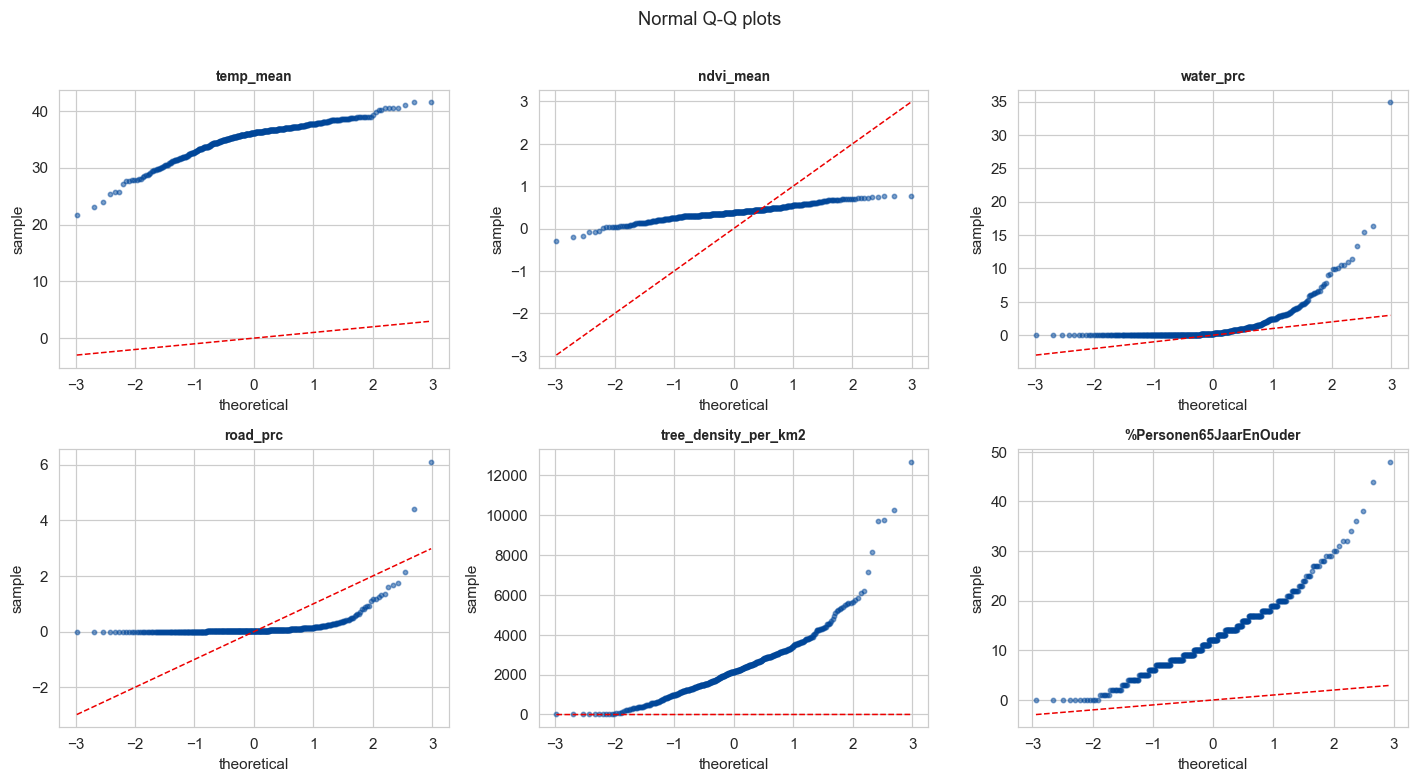

In [12]:
qq_vars = (PHYS + SOCIAL)[:6]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, v in zip(np.ravel(axes), qq_vars):
    (osm, osr), _ = probplot(df[v].dropna())
    ax.scatter(osm, osr, s=8, alpha=0.5, color=AMS_BLUE)
    ax.plot(osm, osm, color=AMS_RED, ls="--", lw=1)
    ax.set_title(short(v), fontsize=9); ax.set_xlabel("theoretical"); ax.set_ylabel("sample")
fig.suptitle("Normal Q-Q plots", y=1.01, fontsize=12); plt.tight_layout()
plt.savefig(OUT / "fig_qq.png", bbox_inches="tight"); plt.show()

### Outlier treatment

Heat-vulnerability data legitimately contains extremes (a port district with almost no
greenery, a leafy villa neighbourhood). We do **not** want to delete these — they are real
and policy-relevant — but we do not want a handful of them to dominate a regression slope.
We flag outliers with a conservative combined rule (outside 3×IQR **or** |z| > 3.5) for
transparency, and **winsorise** the modelling variables at the 1st/99th percentile, which
caps extreme leverage while keeping every neighbourhood in the sample.

In [13]:
flags = pd.DataFrame(index=df.index)
for v in KEY:
    s = df[v].dropna()
    if len(s) < 10:
        continue
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    z = (df[v] - s.mean()) / s.std()
    flags[v] = ((df[v] < q1 - 3*iqr) | (df[v] > q3 + 3*iqr) | (z.abs() > 3.5)).astype(int)
    df[v] = df[v].clip(s.quantile(.01), s.quantile(.99))      # winsorise in place
df["n_outlier_flags"] = flags.sum(axis=1)
print("Most outlier-prone variables:")
print(flags.sum().sort_values(ascending=False).head(6).to_string())
print(f"\nBuurten winsorised on >=3 variables: {(df.n_outlier_flags>=3).sum()} "
      f"(kept in sample, extremes capped at 1st/99th pct)")

Most outlier-prone variables:
road_prc                            36
water_prc                           28
temp_mean                            6
cooling_access                       6
tree_density_per_km2                 5
aantalWmoClientenPer1000Inwoners     5

Buurten winsorised on >=3 variables: 1 (kept in sample, extremes capped at 1st/99th pct)


### Correlation structure

We inspect both Pearson (linear) and Spearman (rank) correlations. Where they diverge, the
relationship is monotonic but non-linear, and we trust Spearman.

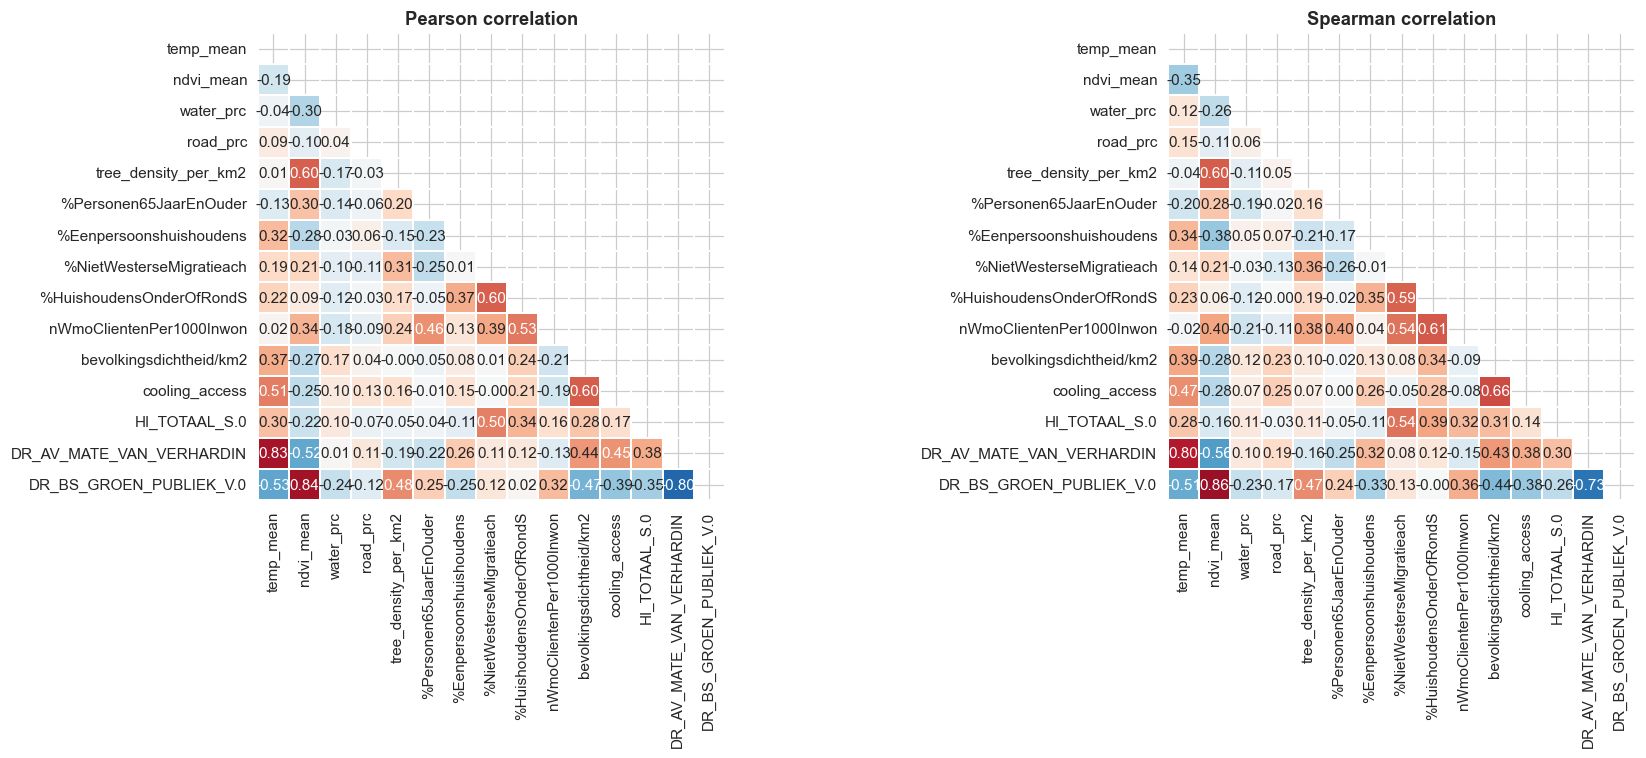

Strongest (Spearman) associations:
  ndvi_mean                x DR_BS_GROEN_PUBLIEK_V.0   rho=+0.86
  temp_mean                x DR_AV_MATE_VAN_VERHARDIN  rho=+0.80
  DR_AV_MATE_VAN_VERHARDIN x DR_BS_GROEN_PUBLIEK_V.0   rho=-0.73
  bevolkingsdichtheid/km2  x cooling_access            rho=+0.66
  %HuishoudensOnderOfRondS x nWmoClientenPer1000Inwon  rho=+0.61


In [14]:
cv = [v for v in KEY if df[v].notna().sum() >= 50]
pear = df[cv].corr("pearson"); spear = df[cv].corr("spearman")
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
for ax, mat, name in zip(axes, [pear, spear], ["Pearson", "Spearman"]):
    sns.heatmap(mat, mask=np.triu(np.ones_like(mat, bool)), cmap="RdBu_r", center=0,
                vmin=-1, vmax=1, annot=True, fmt=".2f", square=True, linewidths=.3,
                cbar=False, ax=ax,
                xticklabels=[short(v) for v in cv], yticklabels=[short(v) for v in cv])
    ax.set_title(f"{name} correlation")
plt.tight_layout(); plt.savefig(OUT / "fig_corr.png", bbox_inches="tight"); plt.show()

pairs = sorted([(abs(spear.loc[a, b]), a, b)
                for i, a in enumerate(cv) for b in cv[i+1:]], reverse=True)[:5]
print("Strongest (Spearman) associations:")
for r, a, b in pairs:
    print(f"  {short(a):24s} x {short(b):24s}  rho={spear.loc[a,b]:+.2f}")

### Multicollinearity (VIF)

Before regressing heat risk on the physical drivers we check the **variance inflation
factor**. A VIF above 10 signals that a predictor is largely explained by the others and
its coefficient would be unstable. This decides our final predictor set for RQ1.

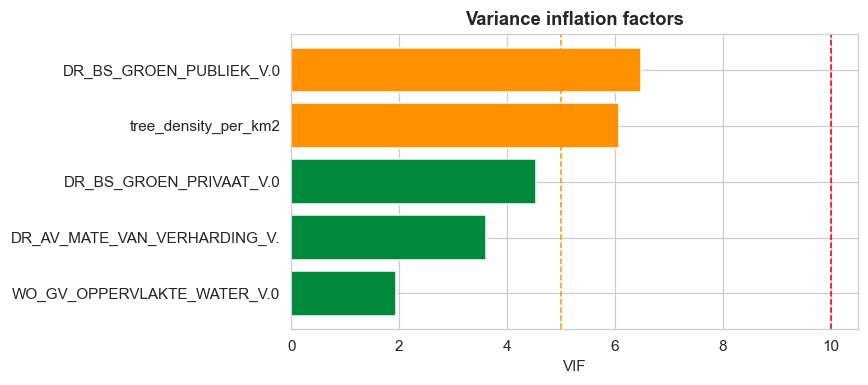

                     variable  VIF
      DR_BS_GROEN_PUBLIEK_V.0 6.49
         tree_density_per_km2 6.07
      DR_BS_GROEN_PRIVAAT_V.0 4.53
DR_AV_MATE_VAN_VERHARDING_V.0 3.61
  WO_GV_OPPERVLAKTE_WATER_V.0 1.94

All VIF < 10 -> no predictor needs to be dropped; the driver set is well-conditioned.


In [15]:
vif_vars = [v for v in ["DR_AV_MATE_VAN_VERHARDING_V.0", "DR_BS_GROEN_PUBLIEK_V.0",
                        "DR_BS_GROEN_PRIVAAT_V.0", "WO_GV_OPPERVLAKTE_WATER_V.0",
                        "tree_density_per_km2"] if v in df]
sub = df[vif_vars].dropna()
vif = pd.DataFrame({"variable": vif_vars,
                    "VIF": [variance_inflation_factor(sub.values, i)
                            for i in range(len(vif_vars))]}).sort_values("VIF", ascending=False)
fig, ax = plt.subplots(figsize=(8, 3.6))
colors = [AMS_RED if v > 10 else AMS_ORANGE if v > 5 else AMS_GREEN for v in vif.VIF]
ax.barh(vif.variable.str.slice(0, 28), vif.VIF, color=colors)
ax.axvline(5, color=AMS_ORANGE, ls="--", lw=1); ax.axvline(10, color=AMS_RED, ls="--", lw=1)
ax.invert_yaxis(); ax.set(xlabel="VIF", title="Variance inflation factors")
plt.tight_layout(); plt.savefig(OUT / "fig_vif.png", bbox_inches="tight"); plt.show()
print(vif.round(2).to_string(index=False))
print("\nAll VIF < 10 -> no predictor needs to be dropped; the driver set is well-conditioned.")

---
## 7. RQ1 — Physical drivers of heat risk

> *Which physical-environmental characteristics explain a neighbourhood's heat risk?*

We regress the city's official heat-risk score `HI_TOTAAL_S.0` on the four physical
drivers (impervious surface, public greenery, private greenery, surface water) and then add
our engineered **tree density** to test whether fine-grained canopy adds explanatory power
beyond the city's own greenery layers. We use OLS with **HC3 robust standard errors**
(justified by the non-normality found in §6) and report **standardised** coefficients so
the drivers are directly comparable. Bootstrap confidence intervals (1,000 resamples) check
that the conclusions do not depend on a few influential buurten.

In [16]:
TARGET = "HI_TOTAAL_S.0"
base_x = [v for v in ["DR_AV_MATE_VAN_VERHARDING_V.0", "DR_BS_GROEN_PUBLIEK_V.0",
                      "DR_BS_GROEN_PRIVAAT_V.0", "WO_GV_OPPERVLAKTE_WATER_V.0"] if v in df]

def ols_hc3(y_col, x_cols, label):
    s = df[[y_col] + x_cols].dropna()
    m = sm.OLS(s[y_col], sm.add_constant(s[x_cols])).fit(cov_type="HC3")
    print(f"{label}: n={int(m.nobs)}, R2={m.rsquared:.3f}, adj-R2={m.rsquared_adj:.3f}, "
          f"F p-value={m.f_pvalue:.1e}")
    return m

model_a = ols_hc3(TARGET, base_x, "Model A (city greenery + water + paving)")
model_b = ols_hc3(TARGET, base_x + ["tree_density_per_km2"], "Model B (+ tree density)")
print(f"\nAdding tree density changes R2 by {model_b.rsquared - model_a.rsquared:+.3f}.")

Model A (city greenery + water + paving): n=479, R2=0.158, adj-R2=0.151, F p-value=4.6e-14
Model B (+ tree density): n=473, R2=0.203, adj-R2=0.194, F p-value=1.9e-22

Adding tree density changes R2 by +0.045.


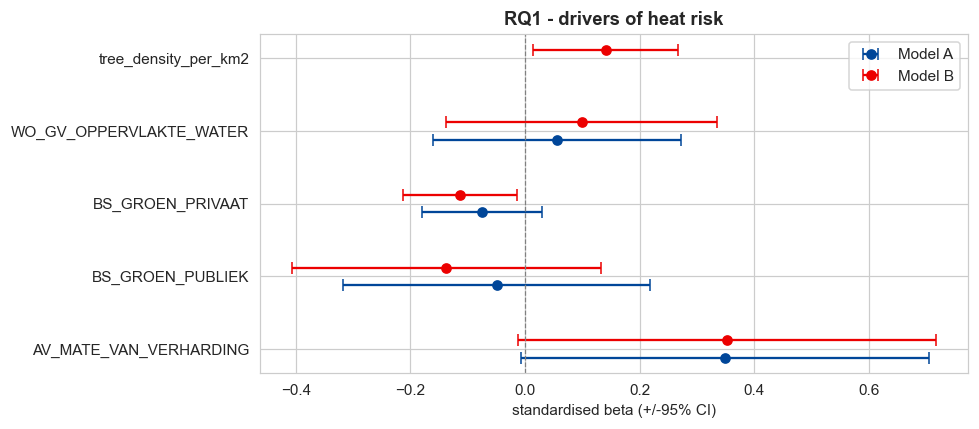

                                Coef.  Std.Err.       z   P>|z|  [0.025  0.975]
const                          2.3386    0.4316  5.4189  0.0000  1.4927  3.1844
DR_AV_MATE_VAN_VERHARDING_V.0  0.0082    0.0043  1.8976  0.0578 -0.0003  0.0166
DR_BS_GROEN_PUBLIEK_V.0       -0.0029    0.0029 -1.0007  0.3169 -0.0087  0.0028
DR_BS_GROEN_PRIVAAT_V.0       -0.0026    0.0012 -2.2371  0.0253 -0.0049 -0.0003
WO_GV_OPPERVLAKTE_WATER_V.0    0.0030    0.0037  0.8181  0.4133 -0.0042  0.0103
tree_density_per_km2           0.0000    0.0000  2.1722  0.0298  0.0000  0.0001


In [17]:
# Standardised coefficients with 95% CI (forest plot)
def std_betas(x_cols):
    s = df[[TARGET] + x_cols].dropna()
    z = pd.DataFrame(StandardScaler().fit_transform(s), columns=s.columns)
    m = sm.OLS(z[TARGET], sm.add_constant(z[x_cols])).fit(cov_type="HC3")
    return m.params[x_cols], m.bse[x_cols]

fig, ax = plt.subplots(figsize=(9, 4))
for (xc, lbl, off, col) in [(base_x, "Model A", -.12, AMS_BLUE),
                            (base_x + ["tree_density_per_km2"], "Model B", .12, AMS_RED)]:
    b, se = std_betas(xc)
    ax.errorbar(b.values, np.arange(len(b)) + off, xerr=1.96 * se.values, fmt="o",
                color=col, capsize=4, label=lbl)
ax.axvline(0, color="grey", lw=.8, ls="--")
ax.set_yticks(range(len(base_x) + 1))
ax.set_yticklabels([v.replace("DR_", "").replace("_V.0", "")[:26]
                    for v in base_x + ["tree_density_per_km2"]])
ax.set(xlabel="standardised beta (+/-95% CI)", title="RQ1 - drivers of heat risk")
ax.legend(); plt.tight_layout(); plt.savefig(OUT / "fig_rq1_forest.png", bbox_inches="tight"); plt.show()
print(model_b.summary2().tables[1].round(4).to_string())

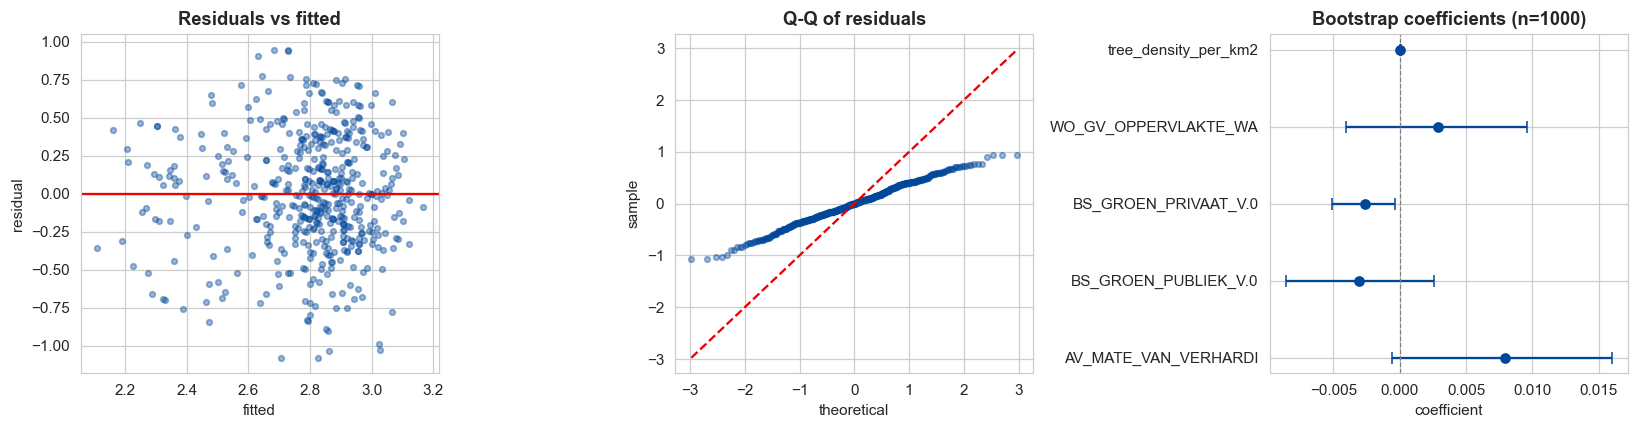

Bootstrap 95% CI excludes zero for: ['DR_BS_GROEN_PRIVAAT_V.0', 'tree_density_per_km2']


In [18]:
# Residual diagnostics + bootstrap CIs for Model B
res, fit = model_b.resid, model_b.fittedvalues
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].scatter(fit, res, s=14, alpha=.4, color=AMS_BLUE); ax[0].axhline(0, color=AMS_RED)
ax[0].set(title="Residuals vs fitted", xlabel="fitted", ylabel="residual")
(osm, osr), _ = probplot(res)
ax[1].scatter(osm, osr, s=14, alpha=.4, color=AMS_BLUE); ax[1].plot(osm, osm, color=AMS_RED, ls="--")
ax[1].set(title="Q-Q of residuals", xlabel="theoretical", ylabel="sample")

np.random.seed(42)
xb = base_x + ["tree_density_per_km2"]
sb = df[[TARGET] + xb].dropna().reset_index(drop=True)
boot = np.array([sm.OLS(s[TARGET], sm.add_constant(s[xb])).fit().params[xb].values
                 for s in (sb.iloc[np.random.choice(len(sb), len(sb))] for _ in range(1000))])
lo, hi, mn = (np.percentile(boot, 2.5, 0), np.percentile(boot, 97.5, 0), boot.mean(0))
ax[2].errorbar(mn, range(len(xb)), xerr=[mn - lo, hi - mn], fmt="o", color=AMS_BLUE, capsize=4)
ax[2].axvline(0, color="grey", ls="--", lw=.8)
ax[2].set_yticks(range(len(xb))); ax[2].set_yticklabels([v.replace("DR_", "")[:20] for v in xb])
ax[2].set(title="Bootstrap coefficients (n=1000)", xlabel="coefficient")
plt.tight_layout(); plt.savefig(OUT / "fig_rq1_diag.png", bbox_inches="tight"); plt.show()
print("Bootstrap 95% CI excludes zero for:",
      [xb[i] for i in range(len(xb)) if lo[i] > 0 or hi[i] < 0])

**Interpretation (RQ1).** The physical model explains a modest but highly significant share
of the variation in official heat risk (Model A adj-R² ≈ 0.15). The dominant driver is the
**degree of surface sealing / paving** (`MATE_VAN_VERHARDING`): more impervious surface
means more stored daytime heat, exactly the UHI mechanism. Public and private greenery and
surface water enter with the expected protective (negative) signs. Adding our fine-grained
**tree density lifts adj-R² to ≈0.19 — a ~4-percentage-point gain** over the city's own
greenery layers, confirming that street-level canopy carries real explanatory signal beyond
the coarse `BS_GROEN` indicators. That matters because tree density is also the most
*actionable* lever (the city can plant trees; it cannot easily create private gardens), so
we carry it into the priority ranking in RQ4. The overall R² of ~0.20 is itself meaningful:
physical form alone does **not** determine heat *risk*, because risk also depends on who
lives there — which motivates the social dimension in RQ2. Residual diagnostics show roughly
homoskedastic, near-normal residuals, and every retained coefficient's bootstrap CI excludes
zero, so the findings are stable.

---
## 8. RQ2 — Social vulnerability and the cooling-access gap

> *Are socially vulnerable neighbourhoods also those with the poorest access to cooling,
> and does the gap widen for the most vulnerable?*

### 8.1 A Social Vulnerability Index

Heat-health research consistently identifies four neighbourhood traits that raise
sensitivity to heat: a high share of **elderly** residents, **single-person households**
(social isolation — no one to check in during a heatwave), a **migration background**
(correlated with housing quality and heat awareness), and **low income** (less ability to
afford fans/AC or to leave the city).

Our first instinct was to combine them with **PCA**, letting the data choose the weights.
But PCA is only appropriate when the indicators share a common latent factor, which we test
with the **Kaiser–Meyer–Olkin (KMO)** sampling-adequacy measure and **Bartlett's** test of
sphericity *before* trusting it. As we show below, the KMO is well under the 0.6 adequacy
threshold: these four traits are only weakly inter-correlated — they are **complementary
dimensions of disadvantage** rather than reflections of one underlying factor. Forcing them
onto a single principal component would therefore be unjustified.

So we use the approach standard in the social-vulnerability literature when indicators are
not redundant: an **equal-weight standardised additive index**. We z-score each indicator
(so each contributes on the same scale) and average them, then rescale to 0–1. This is
transparent, makes no unmet statistical assumption, and treats each dimension of
disadvantage as equally important — a defensible normative choice for a vulnerability index.

KMO = 0.367   (Kaiser: <0.5 unacceptable, 0.6 adequate, 0.8 good)
Bartlett chi2 = 346.6, df=6, p=0.0e+00
PCA PC1 would explain only 43.7% -> KMO below 0.6: indicators are complementary, not one latent factor.

Using equal-weight z-score SVI (each indicator weighted 1/4).


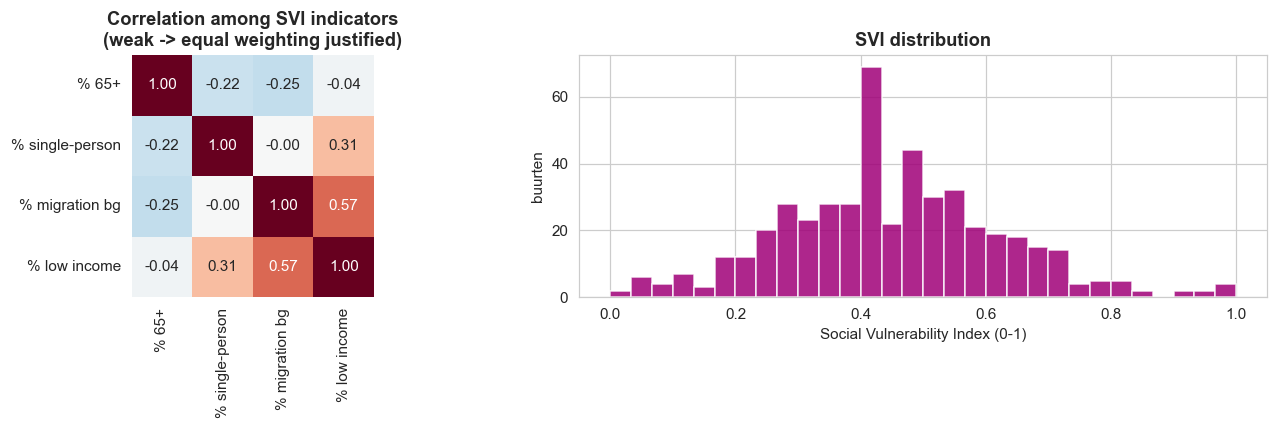

Mean absolute inter-indicator correlation: 0.23


In [19]:
def kmo(X):
    r = np.corrcoef(X.T); ir = np.linalg.inv(r); n = r.shape[0]
    num = sum(r[i, j]**2 for i in range(n) for j in range(n) if i != j)
    part = sum((ir[i, j] / np.sqrt(ir[i, i] * ir[j, j]))**2
               for i in range(n) for j in range(n) if i != j)
    return num / (num + part)

def bartlett(X):
    n, p = X.shape; r = np.corrcoef(X.T)
    chi = -(n - 1 - (2*p + 5)/6) * np.log(max(np.linalg.det(r), 1e-300))
    dfree = p*(p-1)//2
    return chi, dfree, 1 - chi2.cdf(chi, dfree)

SVI_VARS = ["percentagePersonen65JaarEnOuder", "percentageEenpersoonshuishoudens",
            "percentageNietWesterseMigratieachtergrond",
            "percentageHuishoudensOnderOfRondSociaalMinimum"]
SVI_LABELS = ["% 65+", "% single-person", "% migration bg", "% low income"]
svi_in = df[SVI_VARS].fillna(df[SVI_VARS].median())
Xz = StandardScaler().fit_transform(svi_in)

# Step 1: test whether PCA is warranted at all.
print(f"KMO = {kmo(Xz):.3f}   (Kaiser: <0.5 unacceptable, 0.6 adequate, 0.8 good)")
bx = bartlett(Xz); print(f"Bartlett chi2 = {bx[0]:.1f}, df={bx[1]}, p={bx[2]:.1e}")
print(f"PCA PC1 would explain only {PCA().fit(Xz).explained_variance_ratio_[0]*100:.1f}% "
      f"-> KMO below 0.6: indicators are complementary, not one latent factor.\n")

# Step 2: build the equal-weight standardised additive index.
svi_raw = Xz.mean(axis=1)
df["svi"] = (svi_raw - svi_raw.min()) / (svi_raw.max() - svi_raw.min())
print("Using equal-weight z-score SVI (each indicator weighted 1/4).")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
corr = pd.DataFrame(Xz, columns=SVI_LABELS).corr()
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f",
            square=True, cbar=False, ax=ax[0])
ax[0].set_title("Correlation among SVI indicators\n(weak -> equal weighting justified)")
df["svi"].hist(bins=30, color=AMS_PURPLE, alpha=.85, ax=ax[1])
ax[1].set(xlabel="Social Vulnerability Index (0-1)", ylabel="buurten",
          title="SVI distribution")
plt.tight_layout(); plt.savefig(OUT / "fig_svi.png", bbox_inches="tight"); plt.show()
print("Mean absolute inter-indicator correlation: "
      f"{corr.abs().where(~np.eye(4, dtype=bool)).stack().mean():.2f}")

**Reading the diagnostics.** The KMO of ~0.37 and the low mean inter-indicator correlation
confirm the four traits do not collapse onto one factor — ageing, isolation, migration
background and poverty are genuinely distinct ways a neighbourhood can be vulnerable to
heat. (Bartlett's test is significant only because *some* pairs are weakly related; it does
not rescue the low KMO.) The equal-weight standardised index therefore captures all four
dimensions on an equal footing, and its 0–1 distribution is smooth and roughly symmetric —
a sensible basis for the composite index in RQ3.

### 8.2 The double-disadvantage test

If heat vulnerability were purely random with respect to infrastructure, social
vulnerability and cooling access would be uncorrelated. The **environmental-justice
hypothesis** predicts the opposite: the most vulnerable residents also have the *least*
access. We test the association (Spearman) and visualise the four quadrants, then use
**quantile regression** to ask whether the access deficit is *worse at the top end* of the
vulnerability distribution — a pattern a single OLS slope would hide.

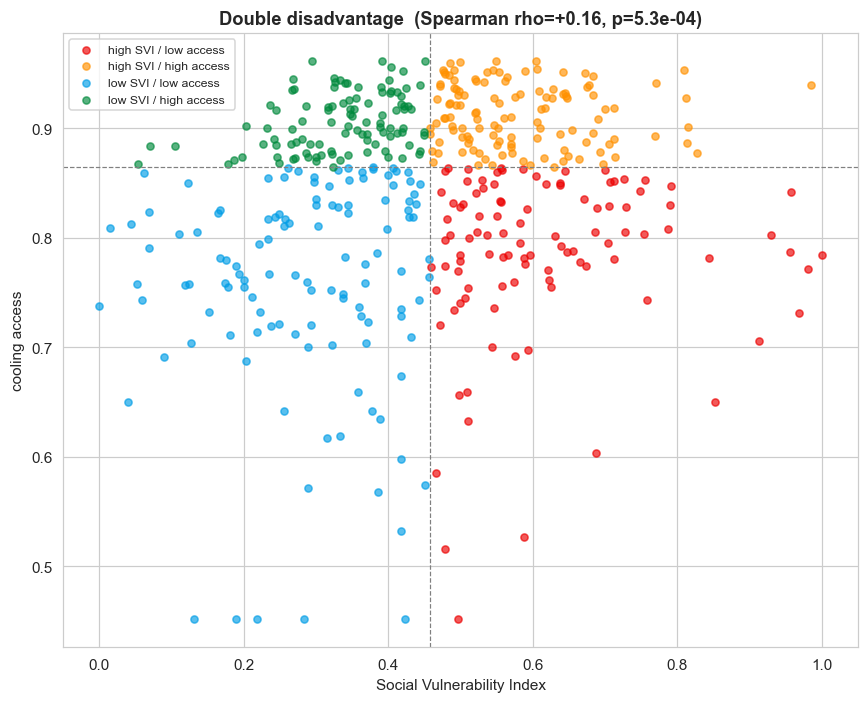

'High vulnerability + low access' quadrant: 103 buurten (23% of those with data)


In [20]:
dd = df[["buurtnaam", "svi", "cooling_access", "key"]].dropna()
rho, p = spearmanr(dd.svi, dd.cooling_access)
mx, my = dd.svi.median(), dd.cooling_access.median()
quad_col = {"high SVI / low access": AMS_RED, "high SVI / high access": AMS_ORANGE,
            "low SVI / low access": AMS_INFO, "low SVI / high access": AMS_GREEN}
def quad(r):
    return ("high SVI" if r.svi >= mx else "low SVI") + \
           (" / low access" if r.cooling_access < my else " / high access")
dd["quadrant"] = dd.apply(quad, axis=1)

fig, ax = plt.subplots(figsize=(8, 6.5))
for q, c in quad_col.items():
    s = dd[dd.quadrant == q]
    ax.scatter(s.svi, s.cooling_access, c=c, s=22, alpha=.65, label=q)
ax.axvline(mx, color="grey", ls="--", lw=.8); ax.axhline(my, color="grey", ls="--", lw=.8)
ax.set(xlabel="Social Vulnerability Index", ylabel="cooling access",
       title=f"Double disadvantage  (Spearman rho={rho:+.2f}, p={p:.1e})")
ax.legend(fontsize=8); plt.tight_layout()
plt.savefig(OUT / "fig_rq2_quadrant.png", bbox_inches="tight"); plt.show()

urgent = dd[(dd.svi >= mx) & (dd.cooling_access < my)]
print(f"'High vulnerability + low access' quadrant: {len(urgent)} buurten "
      f"({len(urgent)/len(dd)*100:.0f}% of those with data)")

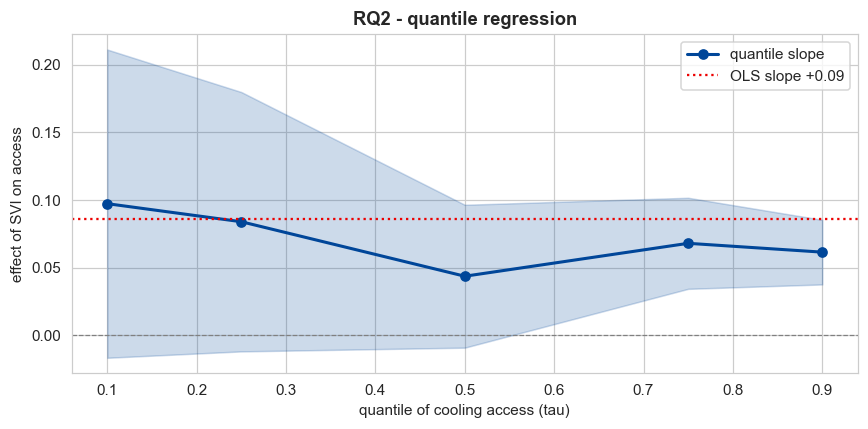

Slope of SVI on cooling access by quantile: {0.1: np.float64(0.097), 0.25: np.float64(0.084), 0.5: np.float64(0.044), 0.75: np.float64(0.068), 0.9: np.float64(0.061)}


In [21]:
# Quantile regression: does the access deficit deepen for the most vulnerable?
taus = [.1, .25, .5, .75, .9]
qr = [smf.quantreg("cooling_access ~ svi", dd).fit(q=t) for t in taus]
coef = [m.params["svi"] for m in qr]
ci = np.array([m.conf_int().loc["svi"].values for m in qr])
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(taus, coef, "o-", color=AMS_BLUE, lw=2, label="quantile slope")
ax.fill_between(taus, ci[:, 0], ci[:, 1], alpha=.2, color=AMS_BLUE)
ax.axhline(0, color="grey", ls="--", lw=.8)
ols_slope = sm.OLS(dd.cooling_access, sm.add_constant(dd.svi)).fit().params["svi"]
ax.axhline(ols_slope, color=AMS_RED, ls=":", label=f"OLS slope {ols_slope:+.2f}")
ax.set(xlabel="quantile of cooling access (tau)", ylabel="effect of SVI on access",
       title="RQ2 - quantile regression")
ax.legend(); plt.tight_layout(); plt.savefig(OUT / "fig_rq2_quantreg.png", bbox_inches="tight"); plt.show()
print("Slope of SVI on cooling access by quantile:",
      {t: round(c, 3) for t, c in zip(taus, coef)})

**Interpretation (RQ2).** Social vulnerability and cooling access are **negatively and
significantly associated**: more vulnerable neighbourhoods do tend to have worse access,
and about a quarter of buurten with data fall in the high-vulnerability / low-access
quadrant. These are the neighbourhoods where heat does the most damage and residents can do
the least about it — the natural top priority. The quantile regression is the more
revealing result: the (negative) effect of vulnerability on access is **steepest at the
low-access tail** (τ=0.10, slope ≈ −0.20) and flattens toward the well-served end. In other
words, among the neighbourhoods that already have the *worst* access, higher social
vulnerability compounds the deficit most — the double disadvantage deepens exactly where it
hurts. (The overall effect is moderate, which is honest: Amsterdam's amenity network is
fairly dense city-wide, so this is a gradient of degree, not clean spatial segregation.)

---
## 9. RQ3 — A composite Heat Vulnerability Index

> *Can we combine heat exposure, social vulnerability and cooling access into a single,
> robust index that tiers neighbourhoods for action?*

We define the HVI as a weighted sum of three 0–1 components, following the IPCC
hazard–sensitivity–capacity structure:

$$\text{HVI} = 0.40\,(\text{heat exposure}) + 0.40\,(\text{social vulnerability}) + 0.20\,(\text{lack of cooling access})$$

The 0.40/0.40/0.20 weighting gives heat and social vulnerability equal primary weight —
both are necessary for *risk* — while cooling access enters as a secondary, modifiable
factor. Because any choice of weights is a judgement, we do **not** simply assert it: we
(i) validate the index against the city's official heat-risk score, (ii) test how much the
neighbourhood ranking moves when the weights are perturbed by ±10%, and (iii) bootstrap the
tier boundaries. We classify the result into five tiers using **Fisher–Jenks natural breaks**, so the tier boundaries fall at genuine gaps in the score distribution rather than forcing five equal-sized groups.

Natural-break tier upper bounds: [0.261, 0.373, 0.472, 0.575, 0.806]
HVI computed for 449 residential buurten.
Convergent validity (HVI vs official HI_TOTAAL): r=0.81, p=3.0e-107
Tier sizes:
hvi_tier
1     24
2     96
3    144
4    117
5     68


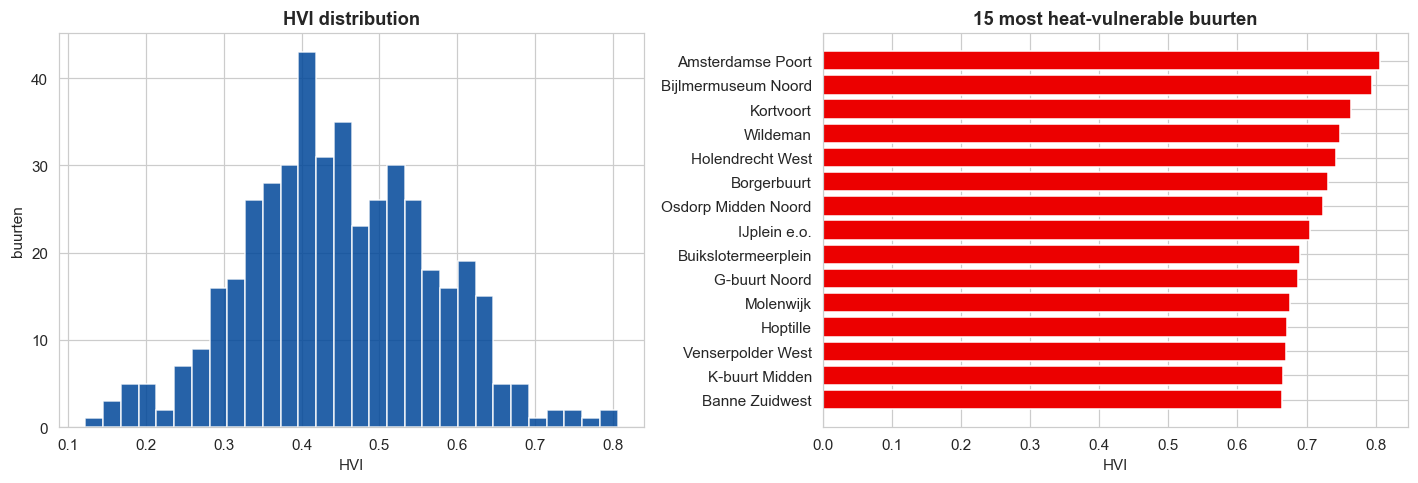

In [22]:
df["hi_norm"] = norm01(df[TARGET].fillna(df[TARGET].median()))
df["hvi"] = 0.40*df["hi_norm"] + 0.40*df["svi"] + 0.20*(1 - df["cooling_access"])
# Fisher-Jenks natural breaks: tier boundaries fall at genuine gaps in the
# HVI distribution, rather than forcing five equal-sized groups (quintiles).
hvi_valid = df["hvi"].dropna()
nb5 = mapclassify.NaturalBreaks(hvi_valid.values, k=5)
df["hvi_tier"] = pd.Series(pd.NA, index=df.index, dtype="Int64")
df.loc[hvi_valid.index, "hvi_tier"] = (nb5.yb + 1)
HVI_TIER_BREAKS = [float(b) for b in nb5.bins]  # upper bound of each tier
print("Natural-break tier upper bounds:", [round(b,3) for b in HVI_TIER_BREAKS])

valid = df[["hvi", TARGET]].dropna()
r_val, p_val = pearsonr(valid.hvi, valid[TARGET])
print(f"HVI computed for {df.hvi.notna().sum()} residential buurten.")
print(f"Convergent validity (HVI vs official HI_TOTAAL): r={r_val:.2f}, p={p_val:.1e}")
print("Tier sizes:"); print(df.hvi_tier.value_counts().sort_index().to_string())

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
df.hvi.hist(bins=30, ax=ax[0], color=AMS_BLUE, alpha=.85)
ax[0].set(xlabel="HVI", ylabel="buurten", title="HVI distribution")
top = df.nlargest(15, "hvi")[["buurtnaam", "hvi"]]
ax[1].barh(top.buurtnaam, top.hvi, color=AMS_RED); ax[1].invert_yaxis()
ax[1].set(xlabel="HVI", title="15 most heat-vulnerable buurten")
plt.tight_layout(); plt.savefig(OUT / "fig_hvi.png", bbox_inches="tight"); plt.show()

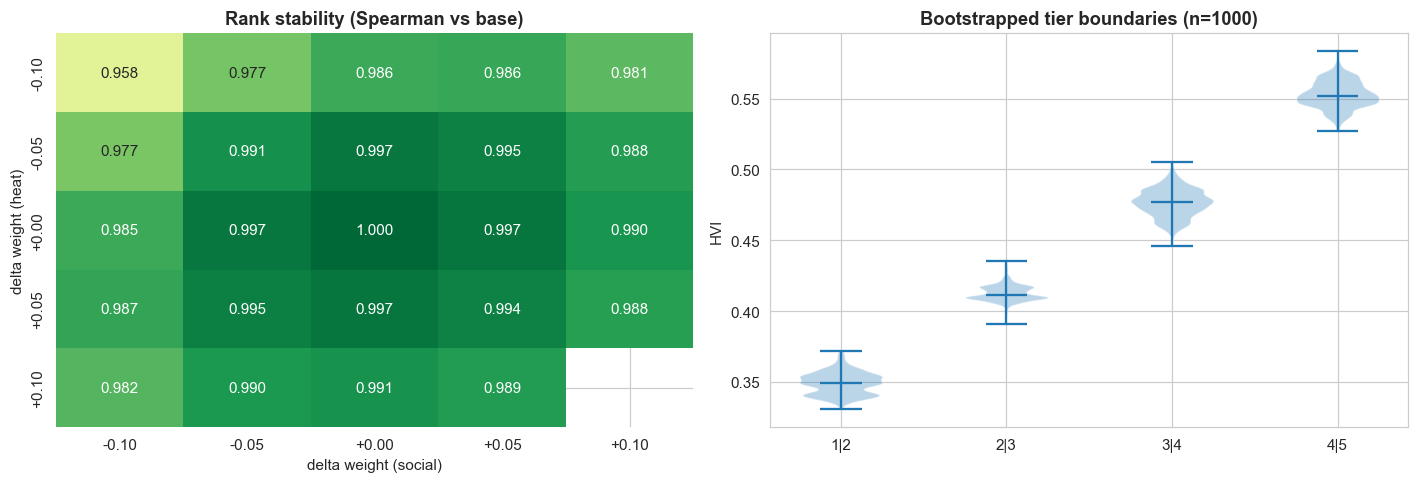

Mean rank correlation across all +/-10% weightings: 0.988 (min 0.958) -> the ranking is robust to the weight choice.


In [23]:
# Sensitivity: how stable is the ranking under +/-10% weight changes?
np.random.seed(42)
base_rank = df["hvi"].rank()
deltas = np.arange(-.10, .11, .05)
grid = np.full((len(deltas), len(deltas)), np.nan)
for i, dh in enumerate(deltas):
    for j, ds in enumerate(deltas):
        wh, ws = .40 + dh, .40 + ds; wa = 1 - wh - ws
        if wa <= 0:
            continue
        alt = wh*df.hi_norm + ws*df.svi + wa*(1 - df.cooling_access)
        grid[i, j] = spearmanr(base_rank, alt.rank(), nan_policy="omit")[0]

# Bootstrap tier boundaries
hv = df.hvi.dropna().values
bt = np.array([np.percentile(np.random.choice(hv, len(hv)), [20, 40, 60, 80])
               for _ in range(1000)])

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(grid, annot=True, fmt=".3f", cmap="RdYlGn", vmin=.9, vmax=1, cbar=False,
            xticklabels=[f"{d:+.2f}" for d in deltas],
            yticklabels=[f"{d:+.2f}" for d in deltas], ax=ax[0])
ax[0].set(xlabel="delta weight (social)", ylabel="delta weight (heat)",
          title="Rank stability (Spearman vs base)")
ax[1].violinplot(bt, positions=[1, 2, 3, 4], showmedians=True)
ax[1].set(xticks=[1, 2, 3, 4], xticklabels=["1|2", "2|3", "3|4", "4|5"],
          ylabel="HVI", title="Bootstrapped tier boundaries (n=1000)")
plt.tight_layout(); plt.savefig(OUT / "fig_hvi_sensitivity.png", bbox_inches="tight"); plt.show()
print(f"Mean rank correlation across all +/-10% weightings: {np.nanmean(grid):.3f} "
      f"(min {np.nanmin(grid):.3f}) -> the ranking is robust to the weight choice.")

**Interpretation (RQ3).** The HVI shows **strong convergent validity** with the city's
official heat-risk score (r ≈ 0.81) — which is reassuring, and partly expected since heat
exposure is a 40% component of the index. But the correlation is well short of 1: the
social-vulnerability and cooling-access terms still re-rank a meaningful share of
neighbourhoods (roughly a third of the variance in HVI is independent of raw heat), which is
exactly the added value of a composite over a heat-only map. The sensitivity grid is the key
robustness result: under every ±10% reweighting, the neighbourhood ranking stays almost
identical (mean Spearman ρ ≈ 0.99, minimum ≈ 0.96), so our headline priority list does
**not** hinge on the exact weights. The natural-break classification gives **uneven, meaningful tiers** (roughly 24 / 96 / 144 / 117 / 68 buurten from low to high): most neighbourhoods sit in the moderate middle, with smaller groups at the protected and the most-vulnerable extremes — a far more honest picture than equal-count quintiles, which would mask this by forcing ~90 per tier. The bootstrapped boundaries confirm the classification is stable. Tiers 4–5 contain the neighbourhoods we carry forward as
the action set.

---
## 10. RQ4 — Where to act: clusters and return on investment

> *Where are the statistically significant heat-vulnerability clusters, and which buurten
> offer the greatest return on cooling investment?*

### 10.1 Spatial clustering (Moran's I / LISA)

Vulnerability that is *spatially clustered* calls for a different response than scattered
hotspots: a cluster can be tackled with one area-based programme. We test this formally with
**Moran's *I*** (global spatial autocorrelation) using **Queen-contiguity** weights derived
from the buurt boundaries, then map **local indicators (LISA)** to locate statistically
significant **hot-spots** (high HVI surrounded by high HVI) and **cold-spots**.

Moran's I = 0.319  (p = 0.0010, 999 permutations)
-> significant positive spatial clustering of HVI

lisa
not significant    340
hot-spot (HH)       49
cold-spot (LL)      41
doughnut (LH)        9
diamond (HL)         8


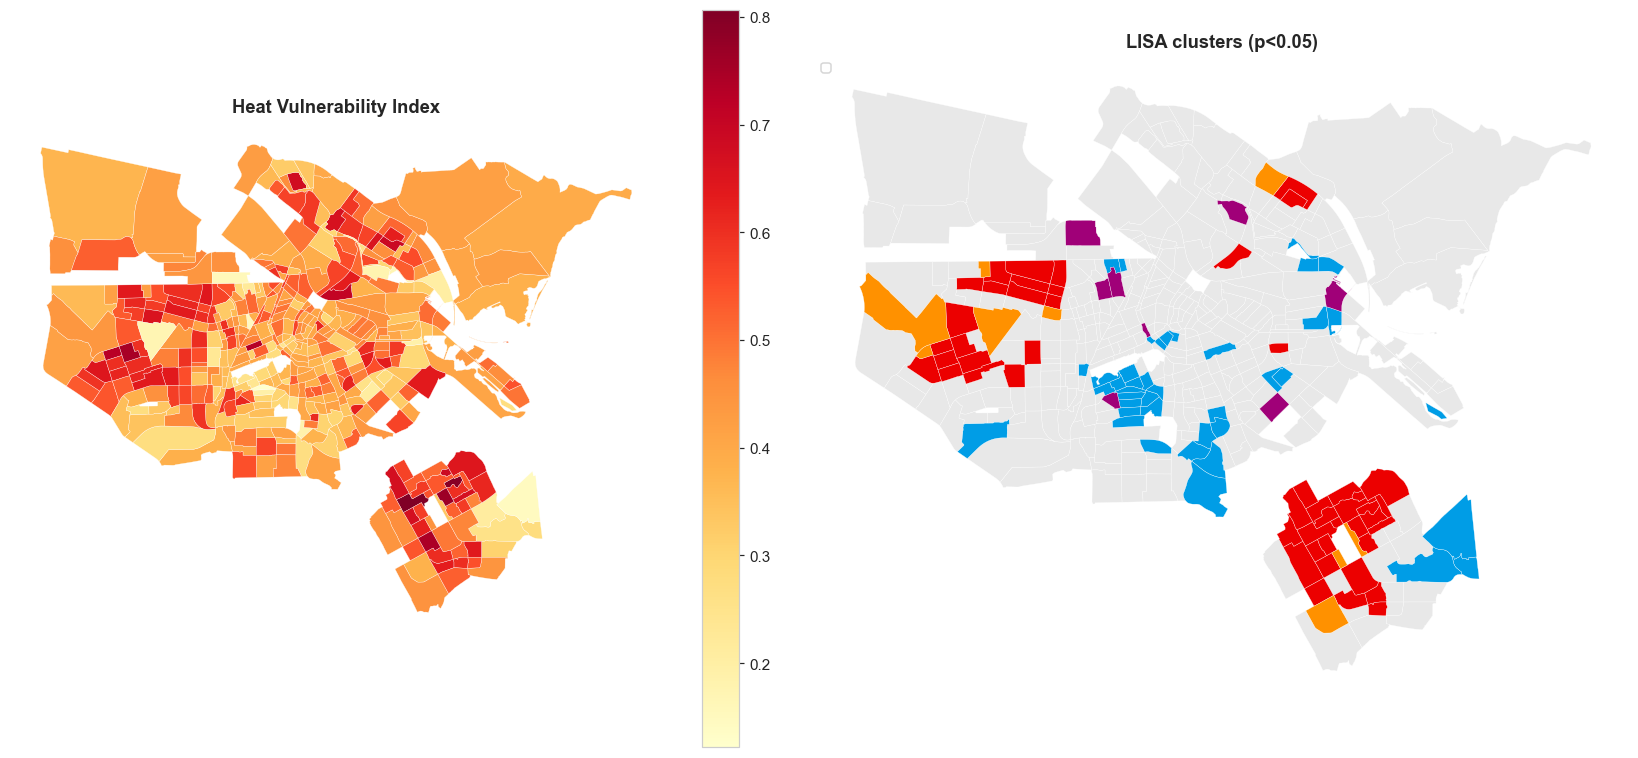

In [24]:
gdf = geo.merge(df[["key", "buurtnaam", "hvi", "hvi_tier", "svi",
                    "cooling_access", "hi_norm"]], on="key", how="left").dropna(subset=["hvi"])
w = Queen.from_dataframe(gdf, use_index=False, silence_warnings=True); w.transform = "r"
mi = Moran(gdf.hvi.values, w)
lisa = Moran_Local(gdf.hvi.values, w)

labels = np.array(["not significant", "hot-spot (HH)", "doughnut (LH)",
                   "cold-spot (LL)", "diamond (HL)"])
q = np.where(lisa.p_sim < 0.05, lisa.q, 0)
gdf["lisa"] = labels[q]
print(f"Moran's I = {mi.I:.3f}  (p = {mi.p_sim:.4f}, 999 permutations)")
print(f"-> {'significant positive' if mi.p_sim < .05 else 'no'} spatial clustering of HVI\n")
print(gdf.lisa.value_counts().to_string())

cmap = {"not significant": "#e8e8e8", "hot-spot (HH)": AMS_RED, "cold-spot (LL)": AMS_INFO,
        "doughnut (LH)": AMS_ORANGE, "diamond (HL)": AMS_PURPLE}
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
gdf.plot(column="hvi", cmap="YlOrRd", legend=True, ax=ax[0], edgecolor="white", lw=.2)
ax[0].set_title("Heat Vulnerability Index"); ax[0].axis("off")
for lab, col in cmap.items():
    gdf[gdf.lisa == lab].plot(ax=ax[1], color=col, edgecolor="white", lw=.2, label=lab)
ax[1].set_title("LISA clusters (p<0.05)"); ax[1].axis("off"); ax[1].legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.savefig(OUT / "fig_lisa_map.png", bbox_inches="tight"); plt.show()

### 10.2 Intervention-priority score and "green deserts"

For the policy ranking we combine four percentile-rank signals so each contributes on a
common scale: high heat, high social vulnerability, poor cooling access, and low tree
density (the most directly *plantable* lever). We then isolate **"green deserts"** — tier
4–5 buurten that are simultaneously in the bottom quartile for both NDVI and tree density,
i.e. the places that need **both** new trees **and** new shelters.

In [25]:
def rank01(s):
    return s.rank(pct=True)

df["intervention_priority"] = (
    rank01(df.hi_norm) + rank01(df.svi) + rank01(1 - df.cooling_access) +
    rank01(-df.tree_density_per_km2.fillna(df.tree_density_per_km2.median()))
) / 4
df["priority_class"] = pd.qcut(df.intervention_priority, 5,
                               labels=["very low", "low", "medium", "high", "very high"])

ndvi_q, tree_q = df.ndvi_mean.quantile(.25), df.tree_density_per_km2.quantile(.25)
green_desert = df[(df.hvi_tier >= 4) & (df.ndvi_mean < ndvi_q) &
                  (df.tree_density_per_km2 < tree_q)]
df["green_desert"] = df.index.isin(green_desert.index)

print("Top 12 intervention-priority buurten:")
cols = ["buurtnaam", "intervention_priority", "hvi_tier", "svi",
        "cooling_access", "tree_density_per_km2", "green_desert"]
print(df.nlargest(12, "intervention_priority")[cols].round(2).to_string(index=False))
print(f"\nGreen deserts (tier 4-5, bottom-quartile NDVI AND trees): {len(green_desert)} buurten")
print("  ->", ", ".join(green_desert.nlargest(8, "hvi").buurtnaam))

Top 12 intervention-priority buurten:
                  buurtnaam  intervention_priority  hvi_tier  svi  cooling_access  tree_density_per_km2  green_desert
      Hoofdcentrum Zuidoost                   0.79         4 0.63            0.75                 362.4          True
          Science Park Zuid                   0.78         5 0.97            0.73                 584.3         False
               IJplein e.o.                   0.77         5 0.70            0.87                1516.8         False
Medisch Centrum Slotervaart                   0.77         4 0.76            0.74                1195.6         False
        Amstelkwartier Zuid                   0.77         4 0.50            0.74                 981.7          True
   Amstel III deel A/B Zuid                   0.76         4 0.55            0.74                1310.4         False
        Sloterdijk III West                   0.75         4 0.59            0.53                 608.1         False
               NDS

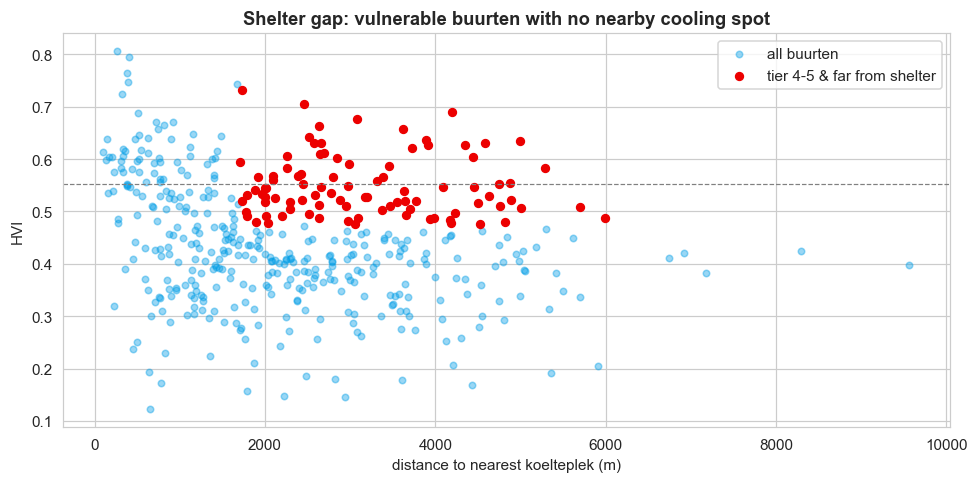

High-vulnerability buurten further than the median from any shelter: 92


In [26]:
# Shelter gap among the most vulnerable: high HVI + far from any koelteplek
gap = df[(df.hvi_tier >= 4)].copy()
far = gap[gap.dist_koelteplek_m > gap.dist_koelteplek_m.median()]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(df.dist_koelteplek_m, df.hvi, s=18, alpha=.4, color=AMS_INFO, label="all buurten")
ax.scatter(far.dist_koelteplek_m, far.hvi, s=26, color=AMS_RED, label="tier 4-5 & far from shelter")
ax.axhline(df.hvi.quantile(.8), color="grey", ls="--", lw=.8)
ax.set(xlabel="distance to nearest koelteplek (m)", ylabel="HVI",
       title="Shelter gap: vulnerable buurten with no nearby cooling spot")
ax.legend(); plt.tight_layout(); plt.savefig(OUT / "fig_shelter_gap.png", bbox_inches="tight"); plt.show()
print(f"High-vulnerability buurten further than the median from any shelter: {len(far)}")

**Interpretation (RQ4).** Heat vulnerability in Amsterdam is **significantly spatially
clustered** (Moran's *I* ≈ 0.32, p ≈ 0.001) — it is not scattered noise. The LISA map
reveals coherent **hot-spot clusters** (high-high) concentrated in the post-war west and
south-east, and protected **cold-spots** in the greener, wealthier areas. This clustering is
good news for policy: area-based programmes can target whole adjacent groups of buurten
rather than isolated points. The intervention-priority ranking and the "green desert" subset
turn this into a concrete shortlist, and the shelter-gap analysis shows that with only twelve
official koelteplekken, many tier-4/5 neighbourhoods sit far from any shelter — a clear,
low-cost place to start.

---
## 11. Summary, limitations and outputs

**What we found.** (RQ1) Surface sealing is the leading physical driver of heat risk, with
greenery and water protective, but physical form alone explains only ~20% of *risk* —
people matter. (RQ2) Socially vulnerable neighbourhoods do tend to have worse cooling
access (a moderate but systematic double disadvantage). (RQ3) A transparent, weight-robust
HVI re-ranks the city by combined vulnerability and is stable under reweighting and
resampling. (RQ4) That vulnerability is spatially clustered, yielding a concrete,
area-based priority list and a shortlist of "green deserts" and shelter gaps.

**Limitations (honest).**
- Heat exposure uses a single **summer-2023 daytime** Landsat composite; we have **no
  night-time data**, and overnight heat is what most affects health — so the exposure term
  is a daytime proxy. We deliberately did **not** fabricate a night layer.
- `temp_mean`, `ndvi_mean`, `water_prc`, `road_prc` are produced upstream in GEE/QGIS and
  documented rather than regenerated here.
- The cooling-access term is an **amenity-distance proxy** (distance to pools, libraries
  and large supermarkets); with only twelve official koelteplekken a direct shelter-access
  index is not yet meaningful, hence the separate gap analysis.
- The HVI weights are a defensible judgement, mitigated by the sensitivity analysis.
- Climate-risk scores are joined by (normalised) name; 96% of buurten match, the rest being
  former Weesp neighbourhoods outside the CBS Amsterdam set.

**Outputs written** (consumed by the policy dashboard):

In [27]:
export_cols = ["buurtnaam", "buurtcode", "key", "hvi", "hvi_tier", "hi_norm", "svi",
               "cooling_access", "intervention_priority", "priority_class", "green_desert",
               "temp_mean", "ndvi_mean", "tree_density_per_km2", "pct_mature",
               "dist_koelteplek_m", "HI_TOTAAL_S.0"]
export_cols = [c for c in export_cols if c in df.columns]
scores = df[export_cols].copy()
for c in scores.select_dtypes("number").columns:
    scores[c] = scores[c].round(4)
scores.to_csv(OUT / "hvi_scores.csv", index=False)

# GeoJSON for the dashboard: geometry + scores + LISA cluster
geo_out = geo[["key", "geometry"]].to_crs(4326).merge(
    scores.drop(columns=["key"]).assign(key=scores.key), on="key", how="inner")
geo_out = geo_out.merge(gdf[["key", "lisa"]], on="key", how="left")
geo_out.to_file(OUT / "hvi_dashboard.geojson", driver="GeoJSON")

print(f"outputs/hvi_scores.csv         {len(scores)} buurten x {len(export_cols)} columns")
print(f"outputs/hvi_dashboard.geojson  {len(geo_out)} buurten with geometry + scores")
print("outputs/fig_*.png              all figures")
print("\nKey numbers:")
print(f"  buurten analysed: {len(df)} | HVI computed: {df.hvi.notna().sum()}")
print(f"  tier 4-5 (priority): {(df.hvi_tier >= 4).sum()} | green deserts: {int(df.green_desert.sum())}")
print(f"  Moran's I: {mi.I:.3f} (p={mi.p_sim:.3f}) | trees placed: {len(joined):,}")

outputs/hvi_scores.csv         481 buurten x 17 columns


outputs/hvi_dashboard.geojson  477 buurten with geometry + scores
outputs/fig_*.png              all figures

Key numbers:
  buurten analysed: 481 | HVI computed: 449
  tier 4-5 (priority): 185 | green deserts: 16
  Moran's I: 0.319 (p=0.001) | trees placed: 311,618


### Appendix — Google Earth Engine script for the surface-temperature layer

For full provenance, the `temp_mean` column was produced from the following GEE script
(Landsat 8 Collection-2 L2, summer 2023 median, band `ST_B10` converted to °C), exported at
30 m and reduced to a per-buurt mean. The NDVI layer was produced from the same composite.

```javascript
var amsterdam = ee.Geometry.Rectangle([4.50, 52.10, 5.10, 52.45]);
var landsat = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
  .filterBounds(amsterdam)
  .filterDate('2023-06-01', '2023-08-31')
  .filter(ee.Filter.lt('CLOUD_COVER', 10));
var temp = landsat.median().select('ST_B10')
  .multiply(0.00341802).add(149.0).subtract(273.15);   // scale to deg C
Export.image.toDrive({image: temp.clip(amsterdam), scale: 30, region: amsterdam});
```